<a href="https://colab.research.google.com/github/Elena-Kazakova-analyst/project-dataset-telecom/blob/main/telecom_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Сегментация клиентской базы телекоммуникационной компании

**Аналитическая задача** — провести анализ данных с целью выделения наиболее типичных групп клиентов и разработки предложений для каждой из групп.

## Описание данных
Каждый клиент описывается следующим набором признаков:
- `Возраст`, `Среднемесячный расход`, `Средняя продолжительность разговоров`, `Звонков днем за месяц`, `Звонков вечером за месяц`, `Звонков ночью за месяц`, `Звонки в другие города`, `Звонки в другие страны`, `Доля звонков на стационарные телефоны`, `Количество SMS за месяц`, `Дата подключения тарифа`.

## Примерный план по выполнению проекта

**Шаг 1.** Загрузка данных;

**Шаг 2.** Первичная обработка данных (при необходимости):
- скорректировать заголовки;
- скорректировать типы признаков;
- проверить наличие дублирующихся записей;
- проверить наличие аномальных значений;
- восстановить пропущенные значения;

**Шаг 3.** Добавление новых переменных:
- по значениям признака `Возраст` введите новую переменную `Возрастная категория`, принимающую значения "студент", "аспирант", "бизнесмен" и "знаток" по следующую правилу:

$$
\text{Возрастная категория} =
\left\{
\begin{array}{l}
\text{студент,} \quad \text{если Возраст } \in [19, 24];\\  
\text{аспирант,} \quad \text{если Возраст } \in [25, 33];\\
\text{бизнесмен,} \quad \text{если Возраст } \in [34, 56];\\
\text{знаток,} \quad \text{если Возраст } \in [57, 70].
\end{array}
\right.
$$

- по значениям признака `Дата подключения тарифа` создайте признаки: `Год подключения`, `Месяц подключения`, `Дата подключения`;  

**Шаг 3.** Провести исследовательский анализ данных:
- в разрезе значений признаков `Год подключения`, `Месяц подключения`, `Дата подключения` исследуйте:
    - динамику подключения к тарифам (количество клиентов). Постройте графики. В какой год, месяц и день подключались меньше/больше всего клиентов? Какие выводы можно сделать?
- в разрезе значений признака `Возрастная категория` исследуйте распределение признаков `Среднемесячный расход`, `Средняя продолжительность разговоров`, `Звонков днем за месяц`, `Звонков вечером за месяц`, `Звонков ночью за месяц`, `Звонки в другие города`, `Доля звонков на стационарные телефоны`, `Количество SMS за месяц`. Для каждого из признаков рассчитайте выборочное среднее, медиану и моду. Постройте графики. Какие выводы можно сделать о предпочтениях клиентов разных возрастных категорий в отношении используемых услуг (звонков и SMS; времени суток);
- клиенты каких возрастных категорий (ТОП-2):
  
    - больше всего в среднем в месяц тратят на оплату услуг связи;
    - больше всего тратят времени на общение в месяц днем, вечером и ночью;
    - больше всего по количеству звонков в месяц днем, вечером и ночью. Совпадают ли результаты с предыдущем пунктом;

- с помощью диаграмм рассеивания исследуейте зависимости между признаками `Среднемесячный расход`, `Средняя продолжительность разговоров`, `Звонков днем за месяц`, `Звонков вечером за месяц`, `Звонков ночью за месяц`, `Звонки в другие города`, `Доля звонков на стационарные телефоны`, `Количество SMS за месяц`. Какие выводы можно сделать?

In [ ]:
# подключение библиотек
import sqlite3
import pandas as pd
import numpy as np

import datetime as dt

import matplotlib.pyplot as plt
import seaborn as sns

**ЗАГРУЗКА ДАННЫХ**

In [ ]:
# создаем подключение к базе данных
df = pd.read_csv('/content/dataset_telecom.csv')

In [ ]:
# просмотр фрагмента загруженных данных
df.head(5)

,Возраст,Среднемесячный расход,Средняя продолжительность разговоров,Звонков днем за месяц,Звонков вечером за месяц,Звонков ночью за месяц,Звонки в другие города,Звонки в другие страны,Доля звонков на стационарные телефоны,Количество SMS за месяц,Дата подключения тарифа
0,24,NaN,2.4,12.0,65.0,5,0,0,5,56,2018-06-17 12:14:35
1,51,287.51,1.7,111.0,109.0,1,44,0,6,1,2021-10-21 15:39:54
2,41,113.70,2.1,41.0,27.0,0,0,0,1,36,2015-03-26 11:26:15
3,35,410.23,5.6,47.0,49.0,0,0,0,11,23,2016-01-04 15:53:20
4,26,537.60,4.8,58.0,77.0,4,0,0,16,29,2017-05-03 13:33:53


In [ ]:
# просмотр информации о типах данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4492 entries, 0 to 4491
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Возраст                                4492 non-null   int64  
 1   Среднемесячный расход                  4468 non-null   float64
 2   Средняя продолжительность разговоров   4475 non-null   float64
 3   Звонков днем за месяц                  4472 non-null   float64
 4   Звонков вечером за месяц               4489 non-null   float64
 5   Звонков ночью за месяц                 4492 non-null   object 
 6   Звонки в другие города                 4492 non-null   object 
 7   Звонки в другие страны                 4492 non-null   int64  
 8   Доля звонков на стационарные телефоны  4492 non-null   object 
 9   Количество SMS за месяц                4492 non-null   object 
 10  Дата подключения тарифа                4492 non-null   object 
dtypes: f

In [ ]:
# просмотр описательных статистик
df.describe()

,Возраст,Среднемесячный расход,Средняя продолжительность разговоров,Звонков днем за месяц,Звонков вечером за месяц,Звонки в другие страны
count,4492.000000,4468.000000,4475.000000,4472.000000,4489.000000,4492.000000
mean,41.894924,505.533577,4.230827,63.899374,70.363778,0.394034
std,13.077254,646.354693,3.005210,62.877394,41.219909,1.171980
min,19.000000,3.180000,0.100000,1.000000,1.000000,0.000000
25%,31.000000,152.490000,2.100000,37.000000,42.000000,0.000000
50%,43.000000,315.510000,3.300000,53.000000,71.000000,0.000000
75%,52.000000,599.840000,5.900000,68.000000,98.000000,0.000000
max,70.000000,5142.760000,20.000000,500.000000,160.000000,12.000000


In [ ]:
display(df.drop(columns=['Возраст', 'Дата подключения тарифа'], errors='ignore').describe())

,Среднемесячный расход,Средняя продолжительность разговоров,Звонков днем за месяц,Звонков вечером за месяц,Звонки в другие страны
count,4468.000000,4475.000000,4472.000000,4489.000000,4492.000000
mean,505.533577,4.230827,63.899374,70.363778,0.394034
std,646.354693,3.005210,62.877394,41.219909,1.171980
min,3.180000,0.100000,1.000000,1.000000,0.000000
25%,152.490000,2.100000,37.000000,42.000000,0.000000
50%,315.510000,3.300000,53.000000,71.000000,0.000000
75%,599.840000,5.900000,68.000000,98.000000,0.000000
max,5142.760000,20.000000,500.000000,160.000000,12.000000


In [ ]:
display(df.describe())


,Возраст,Среднемесячный расход,Средняя продолжительность разговоров,Звонков днем за месяц,Звонков вечером за месяц,Звонки в другие страны
count,4492.000000,4468.000000,4475.000000,4472.000000,4489.000000,4492.000000
mean,41.894924,505.533577,4.230827,63.899374,70.363778,0.394034
std,13.077254,646.354693,3.005210,62.877394,41.219909,1.171980
min,19.000000,3.180000,0.100000,1.000000,1.000000,0.000000
25%,31.000000,152.490000,2.100000,37.000000,42.000000,0.000000
50%,43.000000,315.510000,3.300000,53.000000,71.000000,0.000000
75%,52.000000,599.840000,5.900000,68.000000,98.000000,0.000000
max,70.000000,5142.760000,20.000000,500.000000,160.000000,12.000000


In [ ]:
df

,Возраст,Среднемесячный расход,Средняя продолжительность разговоров,Звонков днем за месяц,Звонков вечером за месяц,Звонков ночью за месяц,Звонки в другие города,Звонки в другие страны,Доля звонков на стационарные телефоны,Количество SMS за месяц,Дата подключения тарифа
0,24,NaN,2.4,12.0,65.0,5,0,0,5,56,2018-06-17 12:14:35
1,51,287.51,1.7,111.0,109.0,1,44,0,6,1,2021-10-21 15:39:54
2,41,113.70,2.1,41.0,27.0,0,0,0,1,36,2015-03-26 11:26:15
3,35,410.23,5.6,47.0,49.0,0,0,0,11,23,2016-01-04 15:53:20
4,26,537.60,4.8,58.0,77.0,4,0,0,16,29,2017-05-03 13:33:53
...,...,...,...,...,...,...,...,...,...,...,...
4487,40,186.20,3.7,36.0,28.0,2,6,0,12,30,2021-04-10 14:58:23
4488,40,500.68,6.0,46.0,66.0,0,6,0,15,23,2021-09-22 14:52:43
4489,60,470.42,3.5,58.0,129.0,2,4,0,19,5,2019-04-04 17:33:38
4490,38,858.99,9.3,50.0,74.0,0,0,0,28,69,2015-12-30 16:28:26


In [ ]:
df.columns

Index(['Возраст', 'Среднемесячный расход',
       'Средняя продолжительность разговоров', 'Звонков днем за месяц',
       'Звонков вечером за месяц', 'Звонков ночью за месяц',
       'Звонки в другие города', 'Звонки в другие страны',
       'Доля звонков на стационарные телефоны', 'Количество SMS за месяц',
       'Дата подключения тарифа'],
      dtype='object')

In [ ]:
# просмотр уникальных значений категориальных признаков -- поиск возможных ошибок в значениях
lst_cat_vars = ['Возраст', 'Среднемесячный расход',
       'Средняя продолжительность разговоров', 'Звонков днем за месяц',
       'Звонков вечером за месяц', 'Звонков ночью за месяц',
       'Звонки в другие города', 'Звонки в другие страны',
       'Доля звонков на стационарные телефоны', 'Количество SMS за месяц']

for col in lst_cat_vars:
    print(f"------ {col} ----------")
    print(df[col].unique())
    print()
    print(f"------ END ----------")

------ Возраст ----------
[24 51 41 35 26 50 66 36 40 23 29 43 21 37 69 46 48 52 59 27 30 53 38 34
 19 54 45 25 60 68 65 63 31 39 20 44 56 33 49 55 67 47 61 64 32 57 28 42
 70 58 62]

------ END ----------
------ Среднемесячный расход ----------
[   nan 287.51 113.7  ... 470.42 858.99 151.92]

------ END ----------
------ Средняя продолжительность разговоров ----------
[ 2.4   1.7   2.1   5.6   4.8   3.3   4.1   1.1   2.5   1.6  13.8   3.4
   nan  2.    5.1   1.9   2.7   3.5   7.3   2.8   8.4   0.7   7.5   6.4
  5.2   3.8   3.9   2.3   7.6   5.4   2.2  14.4   7.4   3.1   6.    6.6
  0.4   4.3   2.6   7.2   5.3   1.2   2.9   8.3   9.8   9.9   1.5   3.7
  1.3  18.2   9.3   7.    4.4   9.2  15.6   8.8   1.4   4.9   6.2  17.
 11.   11.6   1.8   3.2   8.    6.8   9.4   3.6   4.   12.4   3.    9.6
  8.1   4.2   4.6   5.7   5.    0.6   6.1   8.5   7.9   5.9   9.7  11.4
  0.5   6.7  10.4   6.3   4.7  12.6   1.    7.8   0.1  20.    7.7   8.2
  5.5   0.9  10.2   6.5   5.8  10.   14.8   9.1   7.1

**Признак/ Комментарий**

all /скорректировать заголовки

 Дата подключения тарифа / исправить тип на
 `datetime64`

Звонков ночью за месяц
Звонки в другие города
Звонки в другие страны
Доля звонков на стационарные телефоны
Количество SMS за месяц/ исправить тип на float64


 некоторые признаки /есть пропуски

добавить новый признак/возрастная категория ,т.к. нет категориальных признаков

нет необходимости удалять столбцы

**ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ**

In [ ]:
df.columns

Index(['Возраст', 'Среднемесячный расход',
       'Средняя продолжительность разговоров', 'Звонков днем за месяц',
       'Звонков вечером за месяц', 'Звонков ночью за месяц',
       'Звонки в другие города', 'Звонки в другие страны',
       'Доля звонков на стационарные телефоны', 'Количество SMS за месяц',
       'Дата подключения тарифа'],
      dtype='object')

In [ ]:
# корректировка заголовков
df.columns = ['Возраст', 'Среднемесячный расход',
       'Средняя продолжительность звонка', 'Кол-во звонков днем за месяц',
       'Кол-во звонков вечером за месяц', 'Кол-во звонков ночью за месяц',
       'Кол-во звонков в другие города', 'Кол-во звонков в другие страны',
       'Доля звонков на стационарные телефоны', 'Кол-во SMS за месяц',
       'Дата подключения тарифа']
# приведение заголовков к нижнему регистру
df.columns = df.columns.str.lower()



In [ ]:
# замена в заголовках символа "пробел" на _
lst_columns_new = []
for col in df.columns:
    lst_columns_new.append('_'.join(col.split()))
df.columns = lst_columns_new

In [ ]:
df

,возраст,среднемесячный_расход,средняя_продолжительность_звонка,кол-во_звонков_днем_за_месяц,кол-во_звонков_вечером_за_месяц,кол-во_звонков_ночью_за_месяц,кол-во_звонков_в_другие_города,кол-во_звонков_в_другие_страны,доля_звонков_на_стационарные_телефоны,кол-во_sms_за_месяц,дата_подключения_тарифа
0,24,NaN,2.4,12.0,65.0,5,0,0,5,56,2018-06-17 12:14:35
1,51,287.51,1.7,111.0,109.0,1,44,0,6,1,2021-10-21 15:39:54
2,41,113.70,2.1,41.0,27.0,0,0,0,1,36,2015-03-26 11:26:15
3,35,410.23,5.6,47.0,49.0,0,0,0,11,23,2016-01-04 15:53:20
4,26,537.60,4.8,58.0,77.0,4,0,0,16,29,2017-05-03 13:33:53
...,...,...,...,...,...,...,...,...,...,...,...
4487,40,186.20,3.7,36.0,28.0,2,6,0,12,30,2021-04-10 14:58:23
4488,40,500.68,6.0,46.0,66.0,0,6,0,15,23,2021-09-22 14:52:43
4489,60,470.42,3.5,58.0,129.0,2,4,0,19,5,2019-04-04 17:33:38
4490,38,858.99,9.3,50.0,74.0,0,0,0,28,69,2015-12-30 16:28:26


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4492 entries, 0 to 4491
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   возраст                                4492 non-null   int64  
 1   среднемесячный_расход                  4468 non-null   float64
 2   средняя_продолжительность_звонка       4475 non-null   float64
 3   кол-во_звонков_днем_за_месяц           4472 non-null   float64
 4   кол-во_звонков_вечером_за_месяц        4489 non-null   float64
 5   кол-во_звонков_ночью_за_месяц          4492 non-null   object 
 6   кол-во_звонков_в_другие_города         4492 non-null   object 
 7   кол-во_звонков_в_другие_страны         4492 non-null   int64  
 8   доля_звонков_на_стационарные_телефоны  4492 non-null   object 
 9   кол-во_sms_за_месяц                    4492 non-null   object 
 10  дата_подключения_тарифа                4492 non-null   object 
dtypes: f

In [ ]:

# pd.to_datetime -- для приведения признаков к дате и времени

df = df.astype({'дата_подключения_тарифа': 'datetime64[s]'},
               errors='ignore')

In [ ]:
# pd.to_numeric -- для приведения признаков к числовым типах (int, float)
def str_to_float(x:str):
    if x.isdigit():
        return float(x)
    else:
        return float(x.replace("'", ''))

lst_col = ['кол-во_звонков_ночью_за_месяц',
           'кол-во_звонков_в_другие_города',
           'доля_звонков_на_стационарные_телефоны',
           'кол-во_sms_за_месяц']

for col in lst_col:
  df[col] = df[col].apply(str_to_float)

In [ ]:
# pd.to_numeric -- для приведения признаков к числовым типах (int, float)

df = df.astype({'кол-во_звонков_в_другие_страны': 'float64'},
               errors='ignore')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4492 entries, 0 to 4491
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype        
---  ------                                 --------------  -----        
 0   возраст                                4492 non-null   int64        
 1   среднемесячный_расход                  4468 non-null   float64      
 2   средняя_продолжительность_звонка       4475 non-null   float64      
 3   кол-во_звонков_днем_за_месяц           4472 non-null   float64      
 4   кол-во_звонков_вечером_за_месяц        4489 non-null   float64      
 5   кол-во_звонков_ночью_за_месяц          4492 non-null   float64      
 6   кол-во_звонков_в_другие_города         4492 non-null   float64      
 7   кол-во_звонков_в_другие_страны         4492 non-null   float64      
 8   доля_звонков_на_стационарные_телефоны  4492 non-null   float64      
 9   кол-во_sms_за_месяц                    4492 non-null   float64      
 10  

In [ ]:
# поиск дублей
df.duplicated().sum()

# если дубли имеются имеются, то они удаляются
df.drop_duplicates(keep='last',
                   inplace=True)

In [ ]:
# создание нового признака возрастная категория
def get_age_category(age):
    if 19 <= age <= 24:
        return 'студент'
    elif 25 <= age <= 33:
        return 'аспирант'
    elif 34 <= age <= 56:
        return 'бизнесмен'
    elif 57 <= age <= 70:
        return 'знаток'
    return 'другое' # For ages outside the defined ranges

df['возрастная_категория'] = df['возраст'].apply(get_age_category)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4492 entries, 0 to 4491
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype        
---  ------                                 --------------  -----        
 0   возраст                                4492 non-null   int64        
 1   среднемесячный_расход                  4468 non-null   float64      
 2   средняя_продолжительность_звонка       4475 non-null   float64      
 3   кол-во_звонков_днем_за_месяц           4472 non-null   float64      
 4   кол-во_звонков_вечером_за_месяц        4489 non-null   float64      
 5   кол-во_звонков_ночью_за_месяц          4492 non-null   float64      
 6   кол-во_звонков_в_другие_города         4492 non-null   float64      
 7   кол-во_звонков_в_другие_страны         4492 non-null   float64      
 8   доля_звонков_на_стационарные_телефоны  4492 non-null   float64      
 9   кол-во_sms_за_месяц                    4492 non-null   float64      
 10  

In [ ]:
# поиск и обработка аномальных записей
# категориальные признаки
lst_vars_cat = ['возрастная_категория']

# непрерывные признаки
lst_vars_cont = [
    'возраст',
    'среднемесячный_расход',
    'средняя_продолжительность_звонка',
    'кол-во_звонков_днем_за_месяц',
    'кол-во_звонков_вечером_за_месяц',
    'кол-во_звонков_ночью_за_месяц',
    'кол-во_звонков_в_другие_города',
    'кол-во_звонков_в_другие_страны',
    'доля_звонков_на_стационарные_телефоны',
    'кол-во_sms_за_месяц'
]

In [ ]:
# поиск и обработка аномальных записей
# категориальные признаки
# обнаружение аномальных значений

df['возрастная_категория'].value_counts()



,count
возрастная_категория,
бизнесмен,2483
аспирант,831
знаток,661
студент,517


Text(0, 0.5, 'Количество клиентов')

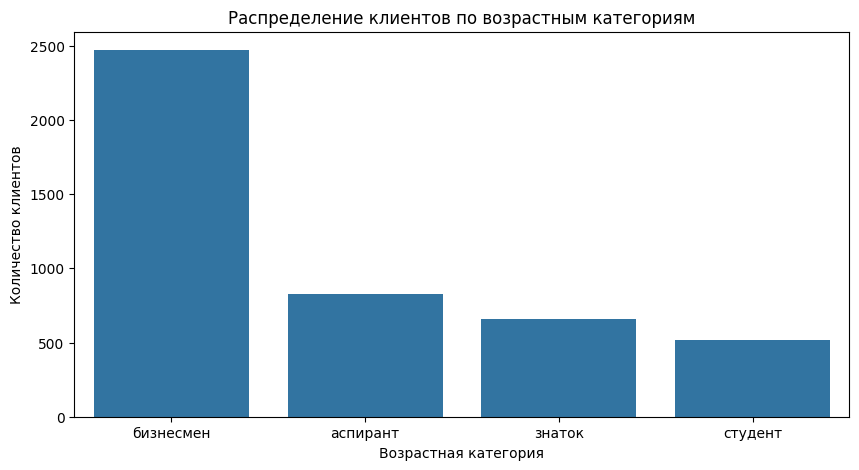

In [ ]:
# визуализация

df_1 = (
    df.groupby('возрастная_категория')
      .agg(count_value = ('среднемесячный_расход', 'count'))
      .sort_values(by='count_value', ascending=False)
      .reset_index()
)
plt.figure(figsize=(10,5))
sns.barplot(x=df_1['возрастная_категория'],
            y=df_1['count_value'])
plt.title('Распределение клиентов по возрастным категориям')
plt.xlabel('Возрастная категория')
plt.ylabel('Количество клиентов')

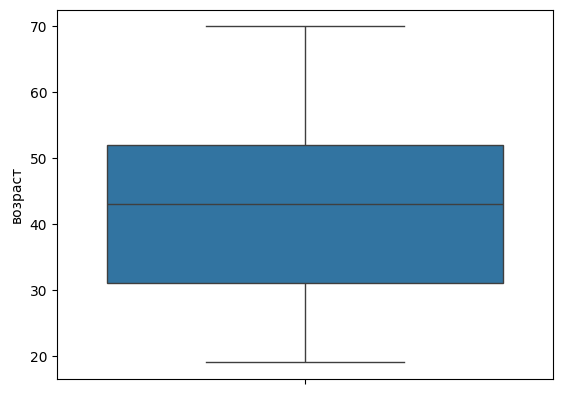

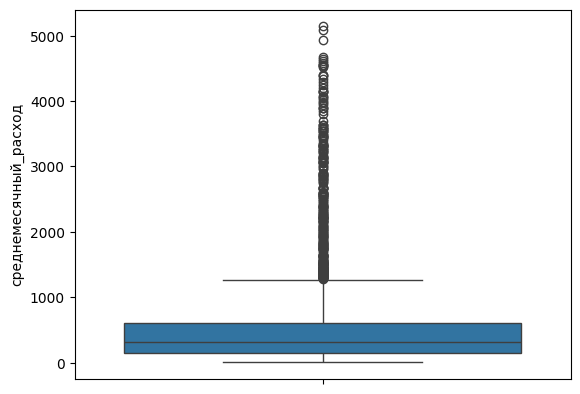

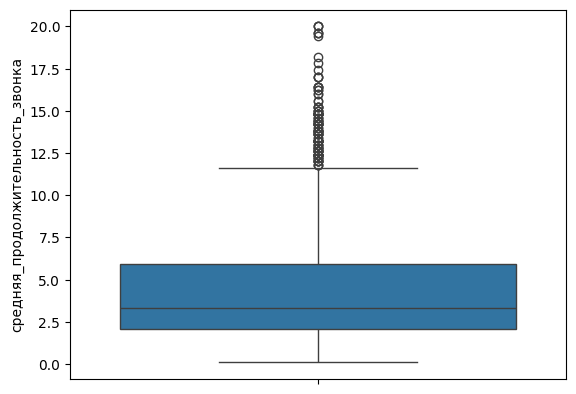

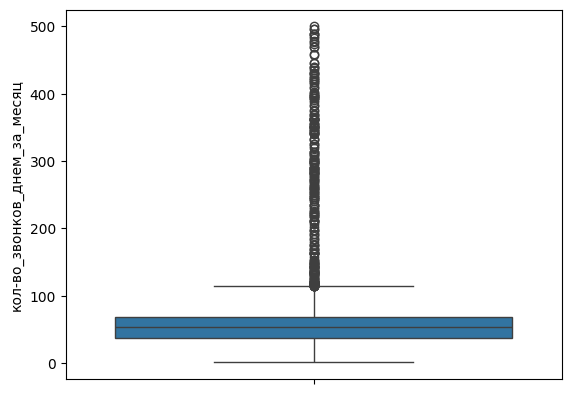

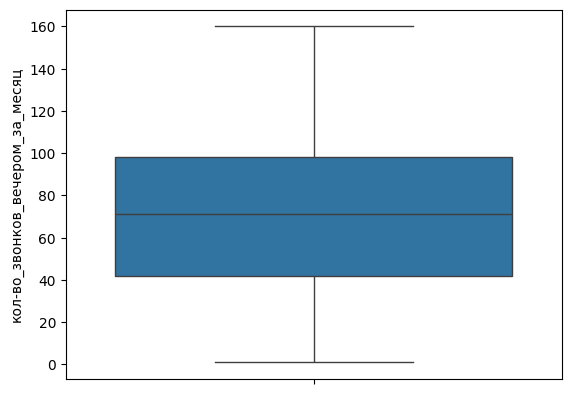

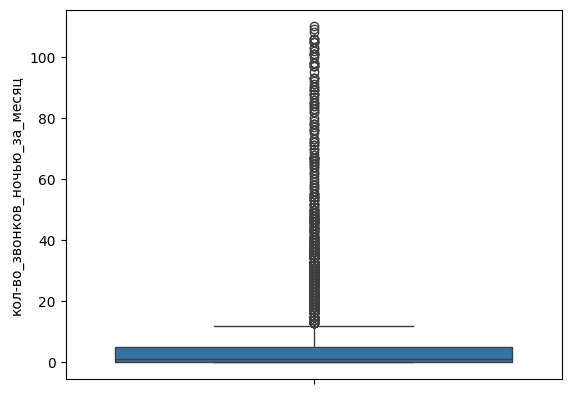

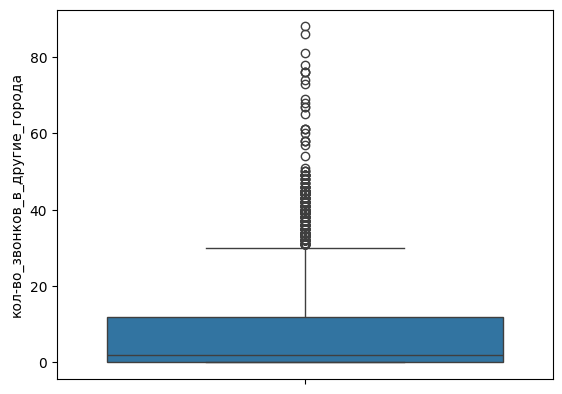

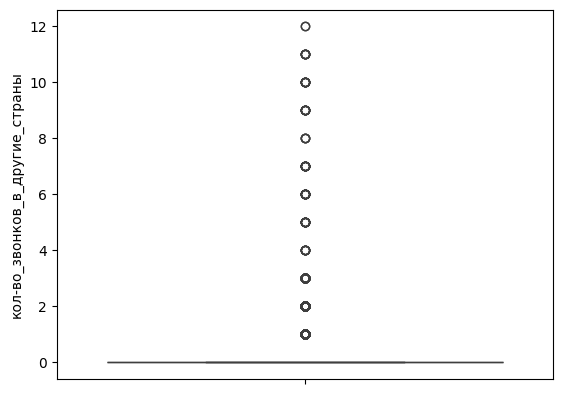

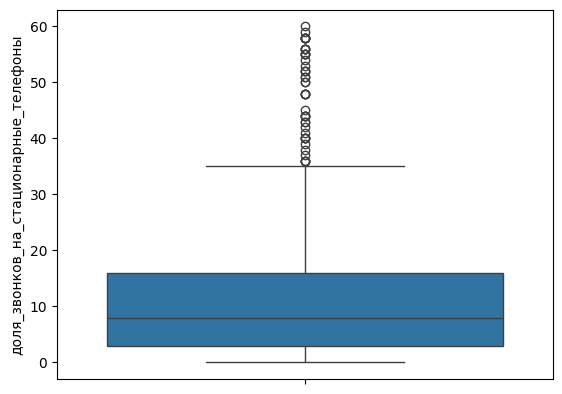

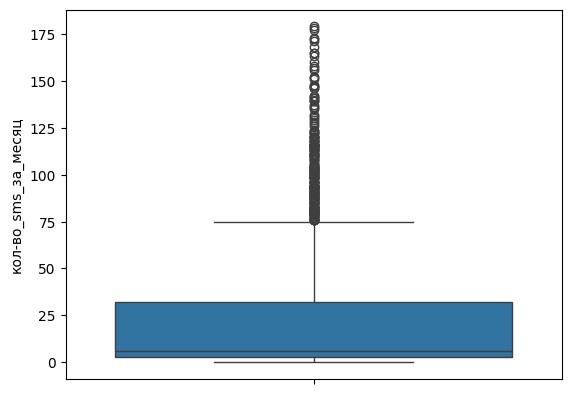

In [ ]:
# непрерывные признаки
# обнаружение аномальных значений
# визуализация непрерывных признаков

for col in lst_vars_cont:
    sns.boxplot(df[col])
    plt.show()

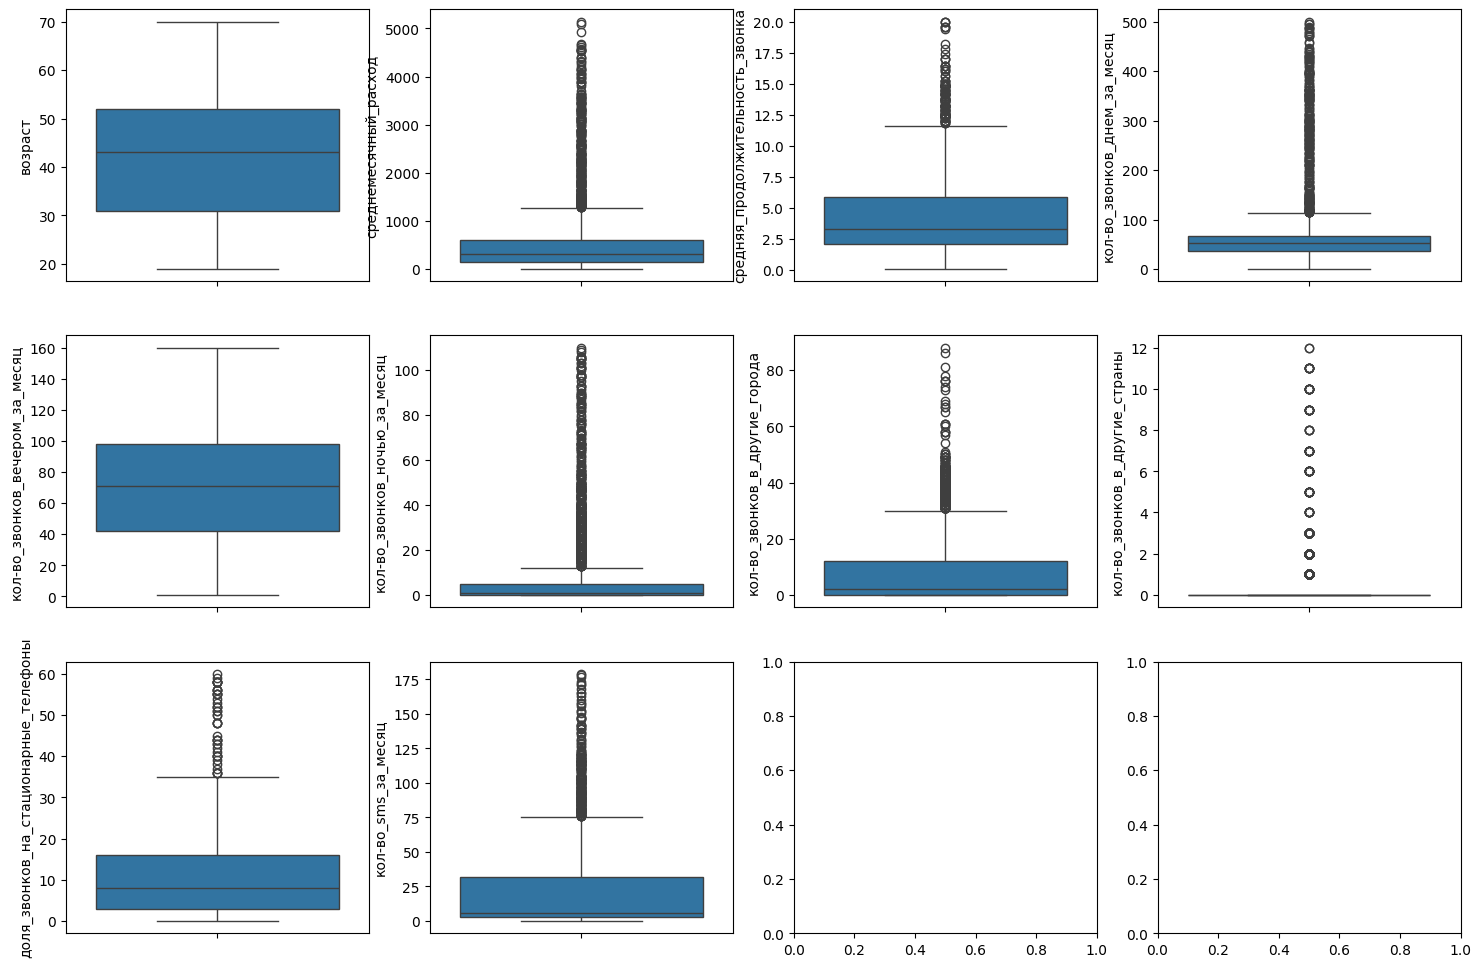

In [ ]:
# графики на сетке
plt.subplots(3,4, figsize=(18,12), gridspec_kw={'wspace': 0.2,
                                               'hspace': 0.2})
index_pic = 1
for col in lst_vars_cont:
    plt.subplot(3,4, index_pic)
    index_pic = index_pic + 1
    sns.boxplot(df[col])

In [ ]:
# Для расчета границ аномальных значений воспользуемся
# заранее подготовленной функцией

# 2 линии нижнего и верхнего усов
#для подсчета значений нижнего и верхнего усов была предложена следующая функция
def calc_boxplot(df_col : pd.Series) -> tuple:

    """
    Функция для расчета значений нижнего и верхнего усов.
    На вход подается столбец датафрейма,
    на выходе кортеж: первый элемент -- нижний ус, второй элемент -- верхний ус
    """

    Q1, median, Q3 = np.percentile(np.asarray(df_col.dropna()), [25, 50, 75])
    IQR = Q3 - Q1
    loval = Q1 - 1.5 * IQR
    hival = Q3 + 1.5 * IQR
    wiskhi = np.compress(np.asarray(df_col.dropna()) <= hival, np.asarray(df_col.dropna()))
    wisklo = np.compress(np.asarray(df_col.dropna()) >= loval, np.asarray(df_col.dropna()))
    actual_hival = np.max(wiskhi)
    actual_loval = np.min(wisklo)
    return actual_loval, actual_hival #(нижний ус, верхний ус)

In [ ]:

filtered = (
    (df['среднемесячный_расход'].between(calc_boxplot(df['среднемесячный_расход'])[0],
                                        df['среднемесячный_расход'].quantile(0.99))) &
    (df['средняя_продолжительность_звонка'].between(calc_boxplot(df['средняя_продолжительность_звонка'])[0],
                                        df['средняя_продолжительность_звонка'].quantile(0.99))) &
    (df['кол-во_звонков_днем_за_месяц'].between(calc_boxplot(df['кол-во_звонков_днем_за_месяц'])[0],
                                  df['кол-во_звонков_днем_за_месяц'].quantile(0.99))) &
    (df['кол-во_звонков_вечером_за_месяц'].between(calc_boxplot(df['кол-во_звонков_вечером_за_месяц'])[0],
                                  df['кол-во_звонков_вечером_за_месяц'].quantile(0.99))) &
    (df['кол-во_звонков_ночью_за_месяц'].between(calc_boxplot(df['кол-во_звонков_ночью_за_месяц'])[0],
                                  df['кол-во_звонков_ночью_за_месяц'].quantile(0.99))) &
    (df['кол-во_звонков_в_другие_города'].between(calc_boxplot(df['кол-во_звонков_в_другие_города'])[0],
                                  df['кол-во_звонков_в_другие_города'].quantile(0.99))) &
    (df['кол-во_звонков_в_другие_страны'].between(calc_boxplot(df['кол-во_звонков_в_другие_страны'])[0],
                                  df['кол-во_звонков_в_другие_страны'].quantile(0.99))) &
    (df['доля_звонков_на_стационарные_телефоны'].between(calc_boxplot(df['доля_звонков_на_стационарные_телефоны'])[0],
                                  df['доля_звонков_на_стационарные_телефоны'].quantile(0.99))) &
    (df['кол-во_sms_за_месяц'].between(calc_boxplot(df['кол-во_sms_за_месяц'])[0],
                                  df['кол-во_sms_за_месяц'].quantile(0.99)))
    )

In [ ]:
# очищенные данные
df.loc[filtered];

# процент потерь
(1 - df.loc[filtered].shape[0] / df.shape[0])*100


7.791629563668745

In [ ]:
# очищенные данные
df_filtered = df.loc[filtered]


# аномальные наблюдения
df_anomals = df.loc[~filtered]

In [ ]:
# пропуски
df.isna().sum()

,0
возраст,0
среднемесячный_расход,24
средняя_продолжительность_звонка,17
кол-во_звонков_днем_за_месяц,20
кол-во_звонков_вечером_за_месяц,3
кол-во_звонков_ночью_за_месяц,0
кол-во_звонков_в_другие_города,0
кол-во_звонков_в_другие_страны,0
доля_звонков_на_стационарные_телефоны,0
кол-во_sms_за_месяц,0


In [ ]:
# Выводы по данному этапу:

# - добавлен новый признак возрастная категория, т.к. первоначально все признаки были непрерывными;
# - скорректированы загозаголовки признаков;
# - исправлены некорректные значения признаков;
# - скорректирован тип признака `дата_подключения_тарифа`;
# - обнаружены и удалены аномальные значения признаков;
# - отдельно по категориальным и непрерывным признакам исследованы
# аномальные значения.
# По непрерывным признакам составлено выражение
# для фильтрации аномальных значений -- процент потерь составил -- 7.79
# от исходного набора --- что является допустимым; аномальные значения выделены
# в отдельный набор и могут в дальнейшем исследоваться дополнительно.


**ГЕНЕРИРОВАНИЕ НОВЫХ ПРИЗНАКОВ**

In [ ]:
# по значениям признака Дата подключения тарифа признаки:Год подключения,
# Месяц подключения, Дата подключения

df['год_подключения'] = df['дата_подключения_тарифа'].dt.year
df['месяц_подключения'] = df['дата_подключения_тарифа'].dt.month
df['день_подключения'] = df['дата_подключения_тарифа'].dt.day

df.head(5)

,возраст,среднемесячный_расход,средняя_продолжительность_звонка,кол-во_звонков_днем_за_месяц,кол-во_звонков_вечером_за_месяц,кол-во_звонков_ночью_за_месяц,кол-во_звонков_в_другие_города,кол-во_звонков_в_другие_страны,доля_звонков_на_стационарные_телефоны,кол-во_sms_за_месяц,дата_подключения_тарифа,возрастная_категория,год_подключения,месяц_подключения,день_подключения
0,24,NaN,2.4,12.0,65.0,5.0,0.0,0.0,5.0,56.0,2018-06-17 12:14:35,студент,2018,6,17
1,51,287.51,1.7,111.0,109.0,1.0,44.0,0.0,6.0,1.0,2021-10-21 15:39:54,бизнесмен,2021,10,21
2,41,113.70,2.1,41.0,27.0,0.0,0.0,0.0,1.0,36.0,2015-03-26 11:26:15,бизнесмен,2015,3,26
3,35,410.23,5.6,47.0,49.0,0.0,0.0,0.0,11.0,23.0,2016-01-04 15:53:20,бизнесмен,2016,1,4
4,26,537.60,4.8,58.0,77.0,4.0,0.0,0.0,16.0,29.0,2017-05-03 13:33:53,аспирант,2017,5,3


**ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ**

**1**. В разрезе значений признаков Год подключения, Месяц подключения, Дата подключения исследуйте:

динамику подключения к тарифам (количество клиентов). Постройте графики. В какой год, месяц и день подключались меньше/больше всего клиентов? Какие выводы можно сделать?

/tmp/ipython-input-2247916634.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conn_by_year.index, y=conn_by_year.values, palette='viridis', legend=False)


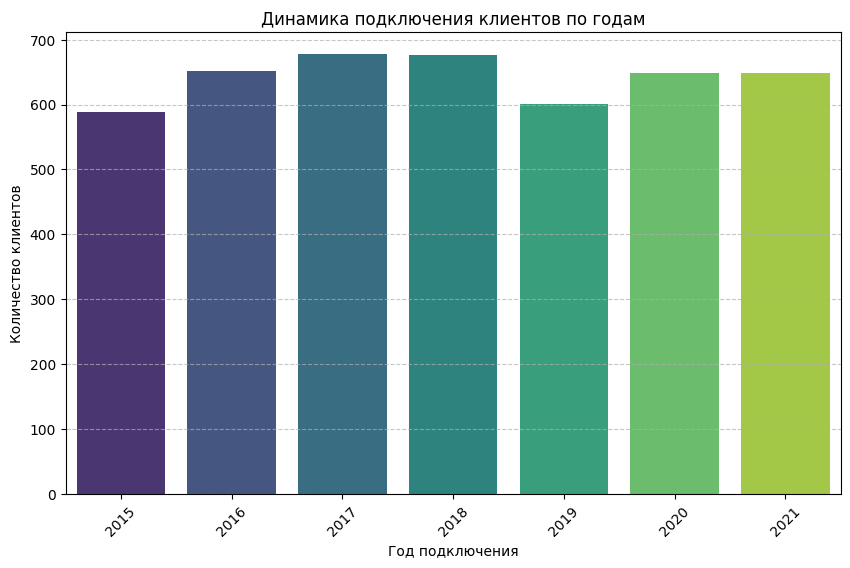

/tmp/ipython-input-2247916634.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conn_by_month.index, y=conn_by_month.values, palette='plasma', legend=False)


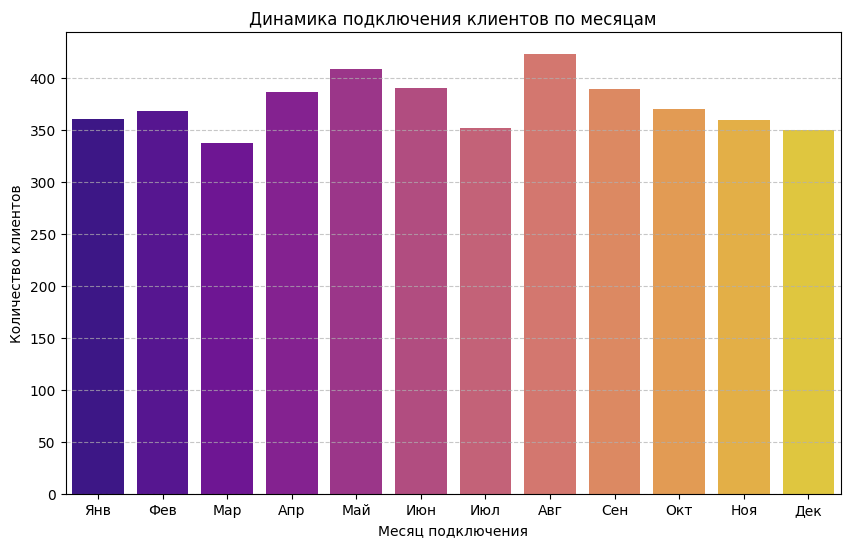

/tmp/ipython-input-2247916634.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conn_by_day.index, y=conn_by_day.values, palette='viridis', legend=False)


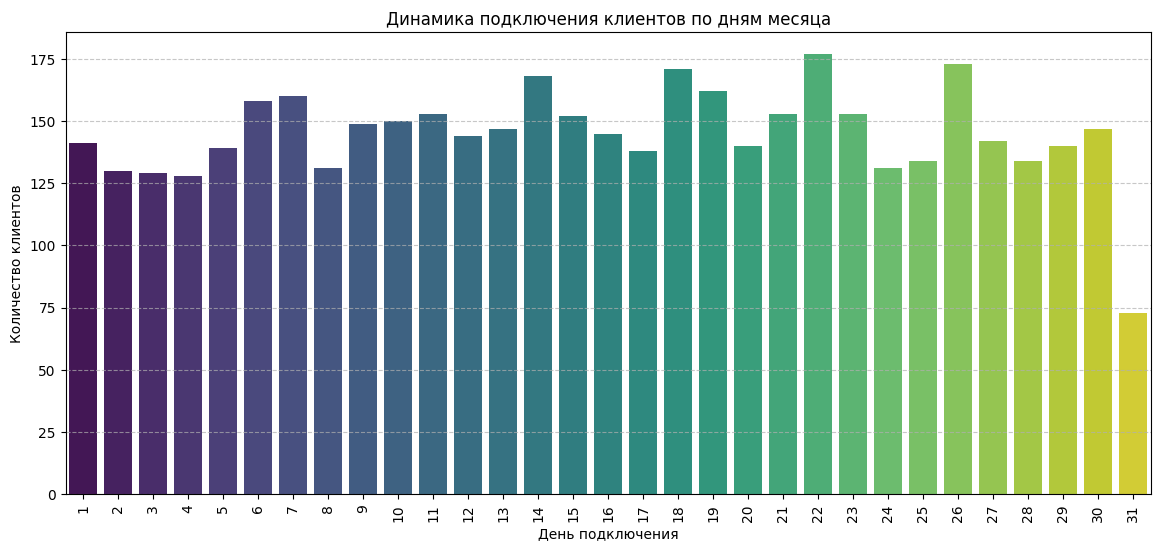

In [ ]:
# Динамика подключения к тарифам по годам
conn_by_year = df['год_подключения'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=conn_by_year.index, y=conn_by_year.values, palette='viridis', legend=False)
plt.title('Динамика подключения клиентов по годам')
plt.xlabel('Год подключения')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Динамика подключения к тарифам по месяцам
conn_by_month = df['месяц_подключения'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=conn_by_month.index, y=conn_by_month.values, palette='plasma', legend=False)
plt.title('Динамика подключения клиентов по месяцам')
plt.xlabel('Месяц подключения')
plt.ylabel('Количество клиентов')
plt.xticks(ticks=range(0,12), labels=['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Динамика подключения к тарифам по дням месяца
conn_by_day = df['день_подключения'].value_counts().sort_index()
plt.figure(figsize=(14, 6))
sns.barplot(x=conn_by_day.index, y=conn_by_day.values, palette='viridis', legend=False)
plt.title('Динамика подключения клиентов по дням месяца')
plt.xlabel('День подключения')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Выводы:/**

Выводы по годам:/
Год с наибольшим количеством подключений: 2017
Год с наименьшим количеством подключений: 2015     
Динамика подключений по годам показывает умеренный рост до 2017 года, после чего наблюдается стабильность до 2018 и далее небольшые спады

Выводы по месяцам:/
Месяц с наибольшим количеством подключений: август
Месяц с наименьшим количеством подключений: март
Активность подключений варьируется в течение года, с пиком летом и спадом весной

Выводы по дням:/
День с наибольшим количеством подключений: 22 число
День с наименьшим количеством подключений: 31 число
Количество подключений снижается к концу месяца, особенно на последний день 31 число

**2**. В разрезе значений признака Возрастная категория исследуйте распределение признаков Среднемесячный расход, Средняя продолжительность разговоров, Звонков днем за месяц, Звонков вечером за месяц, Звонков ночью за месяц, Звонки в другие города, Доля звонков на стационарные телефоны, Количество SMS за месяц. Для каждого из признаков рассчитайте выборочное среднее, медиану и. Постройте графики. Какие выводы можно сделать о предпочтениях клиентов разных возрастных категорий в отношении используемых услуг (звонков и SMS; времени суток);

In [ ]:
(
    df_filtered.groupby('возрастная_категория')[lst_vars_cont]
               .agg(['mean', 'median'])
)

возраст        среднемесячный_расход          \
                           mean median                  mean  median   
возрастная_категория                                                   
аспирант              29.259414   30.0            542.452999  408.00   
бизнесмен             45.494805   46.0            416.447532  320.32   
знаток                61.390244   60.0            320.192439  201.80   
студент               20.586000   20.0            193.718080  133.47   

                     средняя_продолжительность_звонка         \
                                                 mean median   
возрастная_категория                                           
аспирант                                     4.719944    3.9   
бизнесмен                                    3.959459    3.3   
знаток                                       3.387967    2.7   
студент                                      2.672000    2.4   

                     кол-во_звонков_днем_за_месяц         \
                                             mean median   
возрастная_категория                                       
аспирант                                68.677824   59.0   
бизнесмен                               56.646320   55.0   
знаток                                  43.902439   43.0   
студент                                 34.626000   35.0   

                     кол-во_звонков_вечером_за_месяц         \
                                                mean median   
возрастная_категория                                          
аспирант                                   81.348675   79.0   
бизнесмен                                  67.014286   67.0   
знаток                                     51.130081   46.0   
студент                                    67.522000   69.0   

                     кол-во_звонков_ночью_за_месяц         \
                                              mean median   
возрастная_категория                                        
аспирант                                  9.456067    2.0   
бизнесмен                                 2.531602    0.0   
знаток                                    1.282927    0.0   
студент                                   9.120000    7.0   

                     кол-во_звонков_в_другие_города         \
                                               mean median   
возрастная_категория                                         
аспирант                                   9.962343    4.0   
бизнесмен                                  8.919913    2.0   
знаток                                     5.829268    0.0   
студент                                    0.736000    0.0   

                     кол-во_звонков_в_другие_страны         \
                                               mean median   
возрастная_категория                                         
аспирант                                   0.373780    0.0   
бизнесмен                                  0.315584    0.0   
знаток                                     0.203252    0.0   
студент                                    0.076000    0.0   

                     доля_звонков_на_стационарные_телефоны         \
                                                      mean median   
возрастная_категория                                                
аспирант                                         11.146444   10.0   
бизнесмен                                        10.651515   10.0   
знаток                                            9.639024    8.0   
студент                                           3.714000    3.0   

                     кол-во_sms_за_месяц         
                                    mean median  
возрастная_категория                             
аспирант                       33.365411   26.0  
бизнесмен                      13.714719    4.0  
знаток                          2.533333    3.0  
студент                        48.338000   41.0

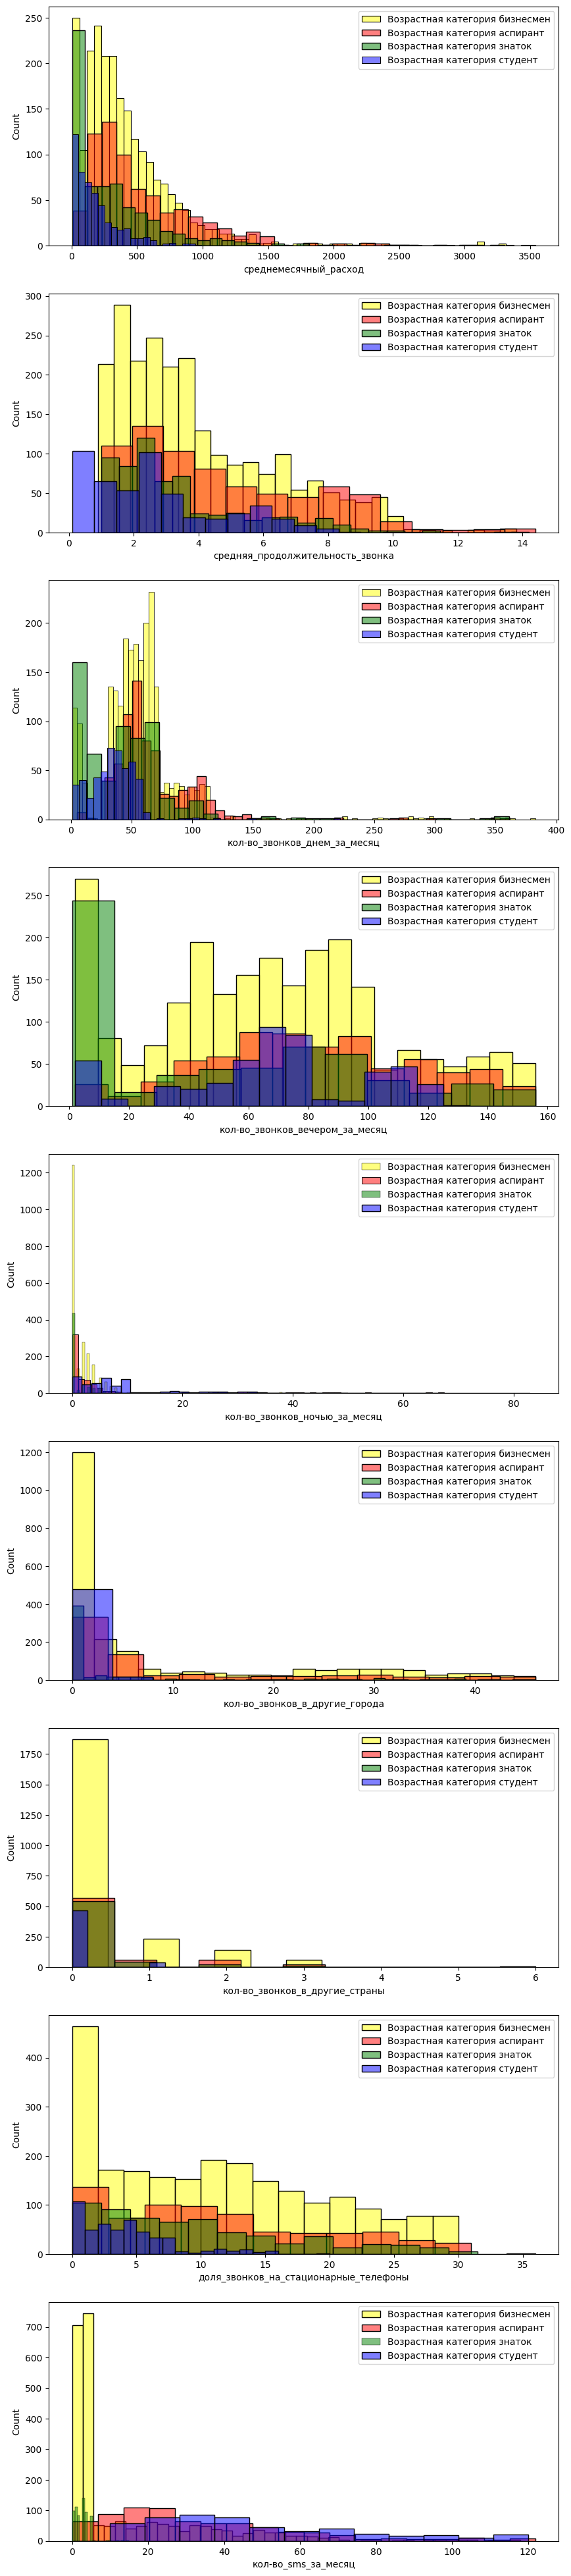

In [ ]:
# визуализация
lst_vars_cont_2 = [
    'среднемесячный_расход',
    'средняя_продолжительность_звонка',
    'кол-во_звонков_днем_за_месяц',
    'кол-во_звонков_вечером_за_месяц',
    'кол-во_звонков_ночью_за_месяц',
    'кол-во_звонков_в_другие_города',
    'кол-во_звонков_в_другие_страны',
    'доля_звонков_на_стационарные_телефоны',
    'кол-во_sms_за_месяц'
]
dct_color = {'аспирант': 'red',
             'бизнесмен': 'yellow',
             'знаток': 'green',
             'студент':'blue'}


plt.subplots(9,1, figsize=(10,50))
for index, col in enumerate(lst_vars_cont_2, start=1):
    plt.subplot(9,1, index)
    for value in df_filtered['возрастная_категория'].unique():
        sns.histplot(x=df_filtered[df_filtered['возрастная_категория'] == value][col],
                     color=dct_color.get(value),
                     alpha=0.5,
                     label=f'Возрастная категория {value}')
        plt.legend()

**Выводы:/**

Студенты :/

 Наименьшие расходы, но очень активны в SMS и умеренно активны в вечерних звонках. Низкая продолжительность разговоров и очень мало звонков на стационарные телефоны. Предпочитают короткие текстовые сообщения и мобильную связь.

Аспиранты :/

 Самые высокие расходы, высокая средняя продолжительность звонков, лидируют по количеству звонков как днем, так и вечером. Активны в SMS, но меньше студентов. Это группа, активно использующая все виды связи.

Бизнесмены:/

 Значительные расходы, но ниже, чем у аспирантов. Умеренная продолжительность звонков, активны днем, но меньше вечером. Низкая активность в SMS. Чаще звонят на стационарные телефоны, что может быть связано с профессиональной деятельностью.

Знатоки/:
 Самые низкие средние расходы , низкая продолжительность разговоров. Меньше всего звонков днем и вечером, минимальное количество SMS и международных звонков. Меньше всего пользуются услугами.

**3**. Клиенты каких возрастных категорий (ТОП-2):

больше всего в среднем в месяц тратят на оплату услуг связи;
больше всего тратят времени на общение в месяц днем, вечером и ночью;
больше всего по количеству звонков в месяц днем, вечером и ночью. Совпадают ли результаты с предыдущем пунктом

In [ ]:
# исследуем распределение значений категориальных признаков в разрезе целевой переменной
lst_to_calc = [
    'среднемесячный_расход',
    'средняя_продолжительность_звонка',
    'кол-во_звонков_днем_за_месяц',
    'кол-во_звонков_вечером_за_месяц',
    'кол-во_звонков_ночью_за_месяц'
]

means_by_age_category = df_filtered.groupby('возрастная_категория')[lst_to_calc].mean()

print(means_by_age_category)

                      среднемесячный_расход  средняя_продолжительность_звонка  \
возрастная_категория                                                            
аспирант                         542.452999                          4.719944   
бизнесмен                        416.447532                          3.959459   
знаток                           320.192439                          3.387967   
студент                          193.718080                          2.672000   

                      кол-во_звонков_днем_за_месяц  \
возрастная_категория                                 
аспирант                                 68.677824   
бизнесмен                                56.646320   
знаток                                   43.902439   
студент                                  34.626000   

                      кол-во_звонков_вечером_за_месяц  \
возрастная_категория                                    
аспирант                                    81.348675   
бизнесмен        

In [ ]:
# определим топ 2
top_categories = {}

for metric in lst_to_calc:
    top_2 = means_by_age_category[metric].nlargest(2)
    top_categories[metric] = top_2

for metric, categories in top_categories.items():
    print(f"\nТОП-2 возрастных категорий по метрике '{metric}':")
    for category, value in categories.items():
      print(f"- {category}: {value:.2f}")



ТОП-2 возрастных категорий по метрике 'среднемесячный_расход':
- аспирант: 542.45
- бизнесмен: 416.45

ТОП-2 возрастных категорий по метрике 'средняя_продолжительность_звонка':
- аспирант: 4.72
- бизнесмен: 3.96

ТОП-2 возрастных категорий по метрике 'кол-во_звонков_днем_за_месяц':
- аспирант: 68.68
- бизнесмен: 56.65

ТОП-2 возрастных категорий по метрике 'кол-во_звонков_вечером_за_месяц':
- аспирант: 81.35
- студент: 67.52

ТОП-2 возрастных категорий по метрике 'кол-во_звонков_ночью_за_месяц':
- аспирант: 9.46
- студент: 9.12


**Выводы:**

Среднемесячный расход и Средняя продолжительность звонка:

ТОП-2: Аспиранты, Бизнесмены

Количество звонков днем за месяц:

ТОП-2: Аспиранты, Бизнесмены

Количество звонков вечером за месяц:

ТОП-2: Аспиранты, Студенты

Количество звонков ночью за месяц:

ТОП-2: Аспиранты, Студенты

данные соответствуют предыдущему пункту

**4**. С помощью диаграмм рассеивания исследуейте зависимости между признаками Среднемесячный расход, Средняя продолжительность разговоров, Звонков днем за месяц, Звонков вечером за месяц, Звонков ночью за месяц, Звонки в другие города, Доля звонков на стационарные телефоны, Количество SMS за месяц. Какие выводы можно сделать?

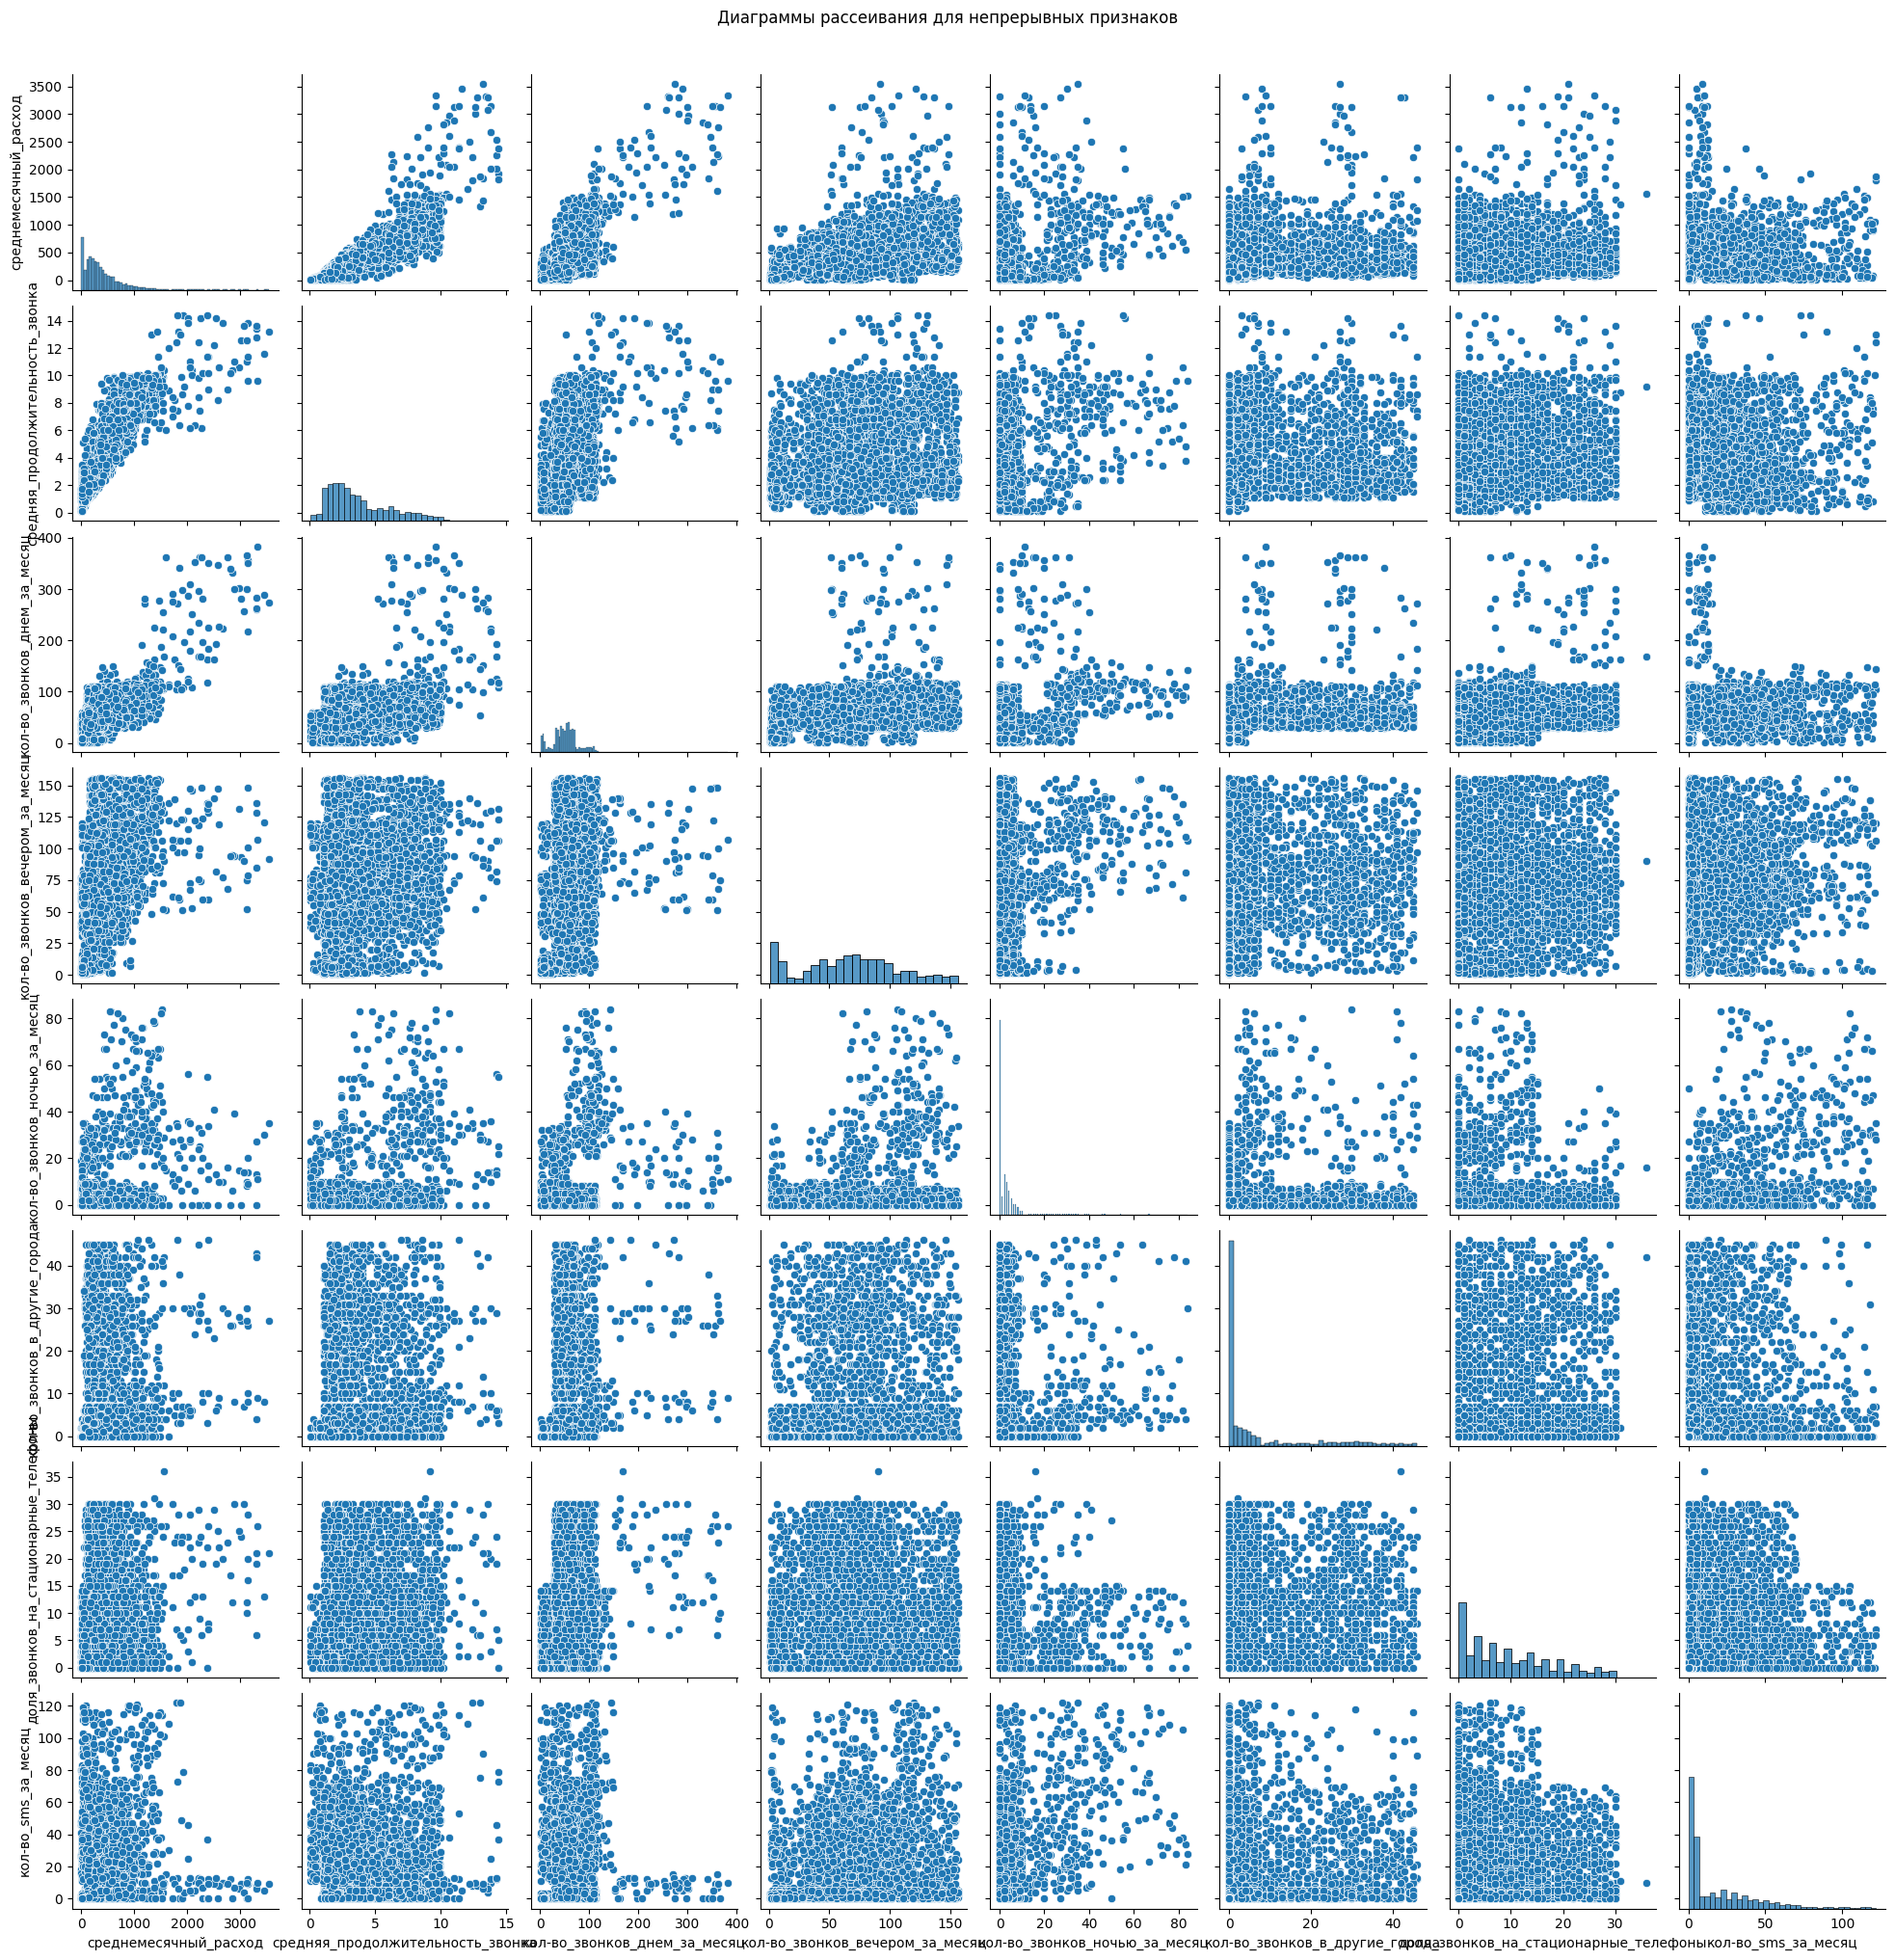

In [ ]:
# Список непрерывных признаков для исследования зависимостей
lst_for_plot = [
    'среднемесячный_расход',
    'средняя_продолжительность_звонка',
    'кол-во_звонков_днем_за_месяц',
    'кол-во_звонков_вечером_за_месяц',
    'кол-во_звонков_ночью_за_месяц',
    'кол-во_звонков_в_другие_города',
    'доля_звонков_на_стационарные_телефоны',
    'кол-во_sms_за_месяц'
]

# Построение матрицы диаграмм рассеивания

sns.pairplot(df_filtered[lst_for_plot], height=2.5)
plt.suptitle('Диаграммы рассеивания для непрерывных признаков', y=1.02)
plt.show()

**Выводы:**

Сильнее всего на среднемесячный расход влияют продолжительность разговоров и количество звонков в дневное время.
Клиенты, совершающие звонки в дневное и вечернее время имеют более высокие счета.
Использование SMS имеет умеренную, но не определяющую связь с общим расходом и длительностью звонков.
Звонки в другие города и на стационарные телефоны оказывают наименьшее влияние на общие расходы.

**ВЫВОДЫ ПО ПРОЕКТУ:**

Основные выводы из анализа данных
Доминирующие категории по основным показателям:
 Аспиранты и Бизнесмены стабильно входят в топ-2 возрастных категорий по показателям среднемесячный расход, средняя продолжительность телефонного разговора и количествово дневных звонков в месяц.

Cуществует зависимость между среднемесячными расходами и средней продолжительностью разговора. Более длительные звонки в этих категориях напрямую приводят к увеличению ежемесячных расходов.

Аспиранты и Студенты входят в топ-2 категорий по показателям количество вечерних звонков в месяц и количество ночных звонков в месяц.
В то время как Знатоки отличаются продолжительностью звонка в вечернее время, Студенты проявляют высокую активность в эти периоды, при этом продолжительность звонков, как правило, меньше.

Целевые предложения для сегментов:

Учитывая сильную взаимосвязь между продолжительностью звонка, его объемом и расходами, рассмотрите возможность разработки тарифных планов для Аспирантов ,Студентов, Бизнесменов и Знатоков.